# Notebook 03 — Skew‑T Log‑P และอุณหพลศาสตร์ของบรรยากาศ

**รายวิชา:** บรรยากาศและคุณภาพอากาศ / Atmosphere and Air Quality  
**ระดับ:** นิสิตสิ่งแวดล้อม ปี 3–4  
**สถานี:** Chiang Mai — WMO **48327**  
**ข้อมูล:** 1 มีนาคม–30 เมษายน 2024  
**เวลา:** **00 UTC = 07:00 ICT**

ลำดับการเรียน:

- Notebook 01 — เตรียมข้อมูลจาก GitHub
- Notebook 02 — เข้าใจ sounding และ QC
- **Notebook 03 — Skew‑T และ atmospheric thermodynamics**
- Notebook 04 — stability, inversion และ air-pollution meteorology
- Notebook 05 — temporal/statistical analysis

Notebook นี้อ่านไฟล์ analysis-ready จาก Google Drive โดยตรง จึงไม่พึ่งตัวแปรใน runtime ของ Notebook 02

## วัตถุประสงค์

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. อ่านองค์ประกอบของ Skew‑T Log‑P
2. สร้าง surface parcel profile
3. อธิบาย LCL, LFC และ EL
4. อธิบาย CAPE และ CIN
5. เปรียบเทียบ SBCAPE, MLCAPE และ MUCAPE
6. คำนวณ precipitable water (PWAT)
7. สร้าง daily thermodynamic diagnostics สำหรับ 61 soundings
8. อธิบายข้อจำกัดของ sounding เวลา 07:00 ICT

## 3.1 แนวคิดของ Skew‑T Log‑P

Skew‑T Log‑P ใช้ pressure เป็นแกนตั้งแบบ logarithmic และใช้อุณหภูมิเป็นแกนเอียง ทำให้สามารถแสดงพร้อมกันได้ทั้ง

- environmental temperature
- dew-point temperature
- dry adiabats
- moist adiabats
- mixing-ratio lines
- wind profile
- parcel trajectory

การอ่าน Skew‑T ที่ดีควรเริ่มจาก **รูปร่างของ profile** ก่อนอ่านตัวเลขดัชนี

In [1]:
!pip -q install metpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 10.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [3]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE_DIR = Path("/content/drive/MyDrive/Teaching_Sounding_AirQuality")
DATA_FILE = BASE_DIR / "01_data" / "chiangmai_48327_00UTC_20240301_20240430.csv.gz"
OUTPUT_DIR = BASE_DIR / "03_output"
FIG_DIR = BASE_DIR / "04_figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Teaching dataset not found. Run 01_get_ChiangMai_sounding_from_GitHub.ipynb first."
    )

df = pd.read_csv(DATA_FILE, compression="gzip")
df["station_id"] = df["station_id"].astype(str).str.replace(r"\.0$", "", regex=True)
df["launch_datetime_utc"] = pd.to_datetime(df["launch_datetime_utc"], errors="coerce")
df["launch_datetime_ict"] = pd.to_datetime(df["launch_datetime_ict"], errors="coerce")

print("Dataset:", DATA_FILE)
print("Rows:", len(df))
print("Soundings:", df["launch_datetime_utc"].nunique())
print("Station:", df["station_id"].dropna().unique())

Dataset: /content/drive/MyDrive/Teaching_Sounding_AirQuality/01_data/chiangmai_48327_00UTC_20240301_20240430.csv.gz
Rows: 4690
Soundings: 61
Station: ['48327']


## 3.2 เลือก Sounding หนึ่งวัน

เริ่มจาก **15 มีนาคม 2024** แล้วค่อยเปลี่ยนวันในแบบฝึกหัด

ก่อนคำนวณด้วย MetPy ต้อง:

1. ตัดระดับที่ขาด pressure, temperature หรือ dew point
2. เรียง pressure จากมากไปน้อย
3. ตัด pressure levels ซ้ำ

นี่เป็น preprocessing ที่สำคัญก่อนคำนวณ thermodynamic indices

In [19]:
SELECTED_DATE = "2024-03-15"

profile = df[
    df["launch_datetime_utc"].dt.strftime("%Y-%m-%d") == SELECTED_DATE
].copy()

if profile.empty:
    raise ValueError(f"No sounding found for {SELECTED_DATE}")

thermo = (
    profile[
        [
            "pressure_hPa", "height_m", "temperature_C", "dewpoint_C",
            "wind_direction_deg", "wind_speed_ms"
        ]
    ]
    .dropna(subset=["pressure_hPa", "temperature_C", "dewpoint_C"])
    .sort_values("pressure_hPa", ascending=False)
    .drop_duplicates(subset="pressure_hPa", keep="first")
    .reset_index(drop=True)
)

pressure = thermo["pressure_hPa"].to_numpy() * units.hPa
temperature = thermo["temperature_C"].to_numpy() * units.degC
dewpoint = thermo["dewpoint_C"].to_numpy() * units.degC

print("Selected date:", SELECTED_DATE)
print("Launch: 00 UTC = 07:00 ICT")
print("Thermodynamic levels:", len(thermo))
display(thermo.head(15))

Selected date: 2024-03-15
Launch: 00 UTC = 07:00 ICT
Thermodynamic levels: 89


,pressure_hPa,height_m,temperature_C,dewpoint_C,wind_direction_deg,wind_speed_ms
0,977.0,314.0,21.4,16.6,0.0,0.0
1,976.0,323.0,22.0,14.6,10.0,8.2
2,975.0,332.0,22.6,12.6,9.0,7.1
3,969.0,386.0,23.3,12.1,0.0,0.0
4,955.0,514.0,24.8,10.8,337.0,0.2
5,925.0,796.0,24.6,11.6,285.0,0.5
6,914.0,901.0,24.6,10.6,304.0,1.4
7,868.0,1350.0,22.0,3.8,25.0,5.2
8,850.0,1532.0,21.0,1.0,40.0,6.2
9,838.0,1655.0,20.4,-0.6,44.0,6.6


## 3.3 Basic Skew‑T

ให้สังเกตก่อนว่า

- \(T\) กับ \(T_d\) อยู่ใกล้กันระดับใด
- มี dry layer ที่ระดับใด
- มี temperature inversion หรือไม่
- environmental profile แตกต่างจาก adiabatic reference lines อย่างไร

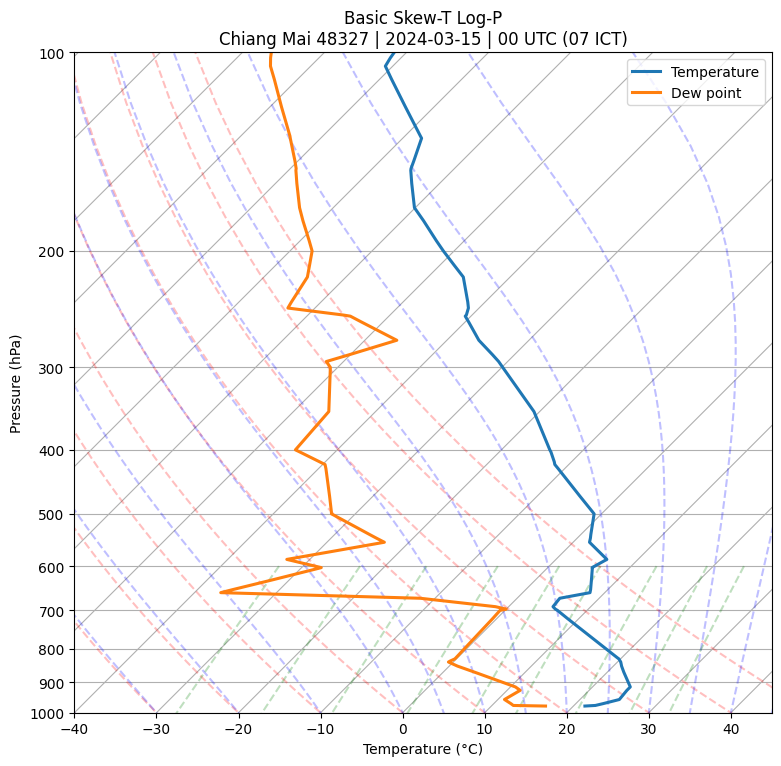

Saved: /content/drive/MyDrive/Teaching_Sounding_AirQuality/04_figures/03_basic_SkewT_2024-03-15.png


In [5]:
fig = plt.figure(figsize=(9, 9))
skew = SkewT(fig, rotation=45)

skew.plot(pressure, temperature, linewidth=2.2, label="Temperature")
skew.plot(pressure, dewpoint, linewidth=2.2, label="Dew point")
skew.plot_dry_adiabats(alpha=0.25)
skew.plot_moist_adiabats(alpha=0.25)
skew.plot_mixing_lines(alpha=0.25)

skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 45)
skew.ax.set_xlabel("Temperature (°C)")
skew.ax.set_ylabel("Pressure (hPa)")
skew.ax.set_title(
    f"Basic Skew-T Log-P\nChiang Mai 48327 | {SELECTED_DATE} | 00 UTC (07 ICT)"
)
skew.ax.legend(loc="best")

basic_fig = FIG_DIR / f"03_basic_SkewT_{SELECTED_DATE}.png"
fig.savefig(basic_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", basic_fig)

## 3.4 Parcel profile และ LCL

เมื่อ parcel ใกล้พื้นถูกยกขึ้น จะเย็นลงแบบ dry adiabatic จนถึงระดับอิ่มตัว

**LCL — Lifted Condensation Level** คือระดับที่ parcel เริ่มอิ่มตัวและการควบแน่นเริ่มเกิดขึ้น

LCL ใช้เป็น thermodynamic estimate ของ cloud-base level แต่ไม่ใช่การวัดฐานเมฆโดยตรง

In [6]:
parcel = mpcalc.parcel_profile(
    pressure,
    temperature[0],
    dewpoint[0]
).to("degC")

lcl_p, lcl_t = mpcalc.lcl(
    pressure[0],
    temperature[0],
    dewpoint[0]
)

print("Surface temperature:", temperature[0])
print("Surface dew point:", dewpoint[0])
print("LCL pressure:", lcl_p.to("hPa"))
print("LCL temperature:", lcl_t.to("degC"))

Surface temperature: 21.4 degree_Celsius
Surface dew point: 16.6 degree_Celsius
LCL pressure: 909.8364465520676 hectopascal
LCL temperature: 15.483883046821518 degree_Celsius


## 3.5 LFC และ EL

**LFC — Level of Free Convection** คือระดับที่ parcel เริ่มมี positive buoyancy และสามารถเร่งตัวขึ้นได้เอง

**EL — Equilibrium Level** คือระดับด้านบนที่ buoyancy กลับมาใกล้ศูนย์

บริเวณระหว่าง LFC และ EL เป็นส่วนสำคัญในการสะสม CAPE

In [7]:
def safe_lfc(p, t, td, parcel_profile):
    try:
        return mpcalc.lfc(
            p, t, td,
            parcel_temperature_profile=parcel_profile
        )
    except TypeError:
        return mpcalc.lfc(p, t, td, parcel_profile)

def safe_el(p, t, td, parcel_profile):
    try:
        return mpcalc.el(
            p, t, td,
            parcel_temperature_profile=parcel_profile
        )
    except TypeError:
        return mpcalc.el(p, t, td, parcel_profile)

lfc_p, lfc_t = safe_lfc(pressure, temperature, dewpoint, parcel)
el_p, el_t = safe_el(pressure, temperature, dewpoint, parcel)

print("LFC pressure:", lfc_p)
print("LFC temperature:", lfc_t)
print("EL pressure:", el_p)
print("EL temperature:", el_t)

LFC pressure: nan hectopascal
LFC temperature: nan degree_Celsius
EL pressure: nan hectopascal
EL temperature: nan degree_Celsius


## 3.6 CAPE และ CIN

CAPE คือ positive buoyant energy:

\[
CAPE =
\int_{LFC}^{EL}
g\frac{T_{vp}-T_{ve}}{T_{ve}}\,dz
\]

หน่วย \(J\,kg^{-1}\)

CIN คือ negative buoyant energy ที่ต้านการยกตัวของ parcel

CAPE สูงไม่ได้หมายความว่าจะเกิด convection แน่นอน เพราะ initiation ยังขึ้นกับ trigger, CIN, moisture และ wind shear

In [8]:
sbcape, sbcin = mpcalc.cape_cin(
    pressure,
    temperature,
    dewpoint,
    parcel
)

print("SBCAPE:", sbcape.to("J/kg"))
print("SBCIN :", sbcin.to("J/kg"))

SBCAPE: 0 joule / kilogram
SBCIN : 0 joule / kilogram


## 3.7 SBCAPE, MLCAPE และ MUCAPE

- **SBCAPE** ใช้ parcel ที่ผิวพื้น
- **MLCAPE** ใช้ parcel เฉลี่ยใน mixed layer ใกล้พื้น เช่น 100 hPa
- **MUCAPE** เลือก parcel ที่ unstable มากที่สุดในชั้นล่างที่กำหนด

Parcel definition ต่างกัน จึงไม่ควรคาดหวังว่าค่า CAPE ทั้งสามชนิดจะเท่ากัน

In [9]:
try:
    mlcape, mlcin = mpcalc.mixed_layer_cape_cin(
        pressure, temperature, dewpoint,
        depth=100 * units.hPa
    )
except Exception as exc:
    print("MLCAPE warning:", exc)
    mlcape = np.nan * units("J/kg")
    mlcin = np.nan * units("J/kg")

try:
    mucape, mucin = mpcalc.most_unstable_cape_cin(
        pressure, temperature, dewpoint,
        depth=300 * units.hPa
    )
except Exception as exc:
    print("MUCAPE warning:", exc)
    mucape = np.nan * units("J/kg")
    mucin = np.nan * units("J/kg")

cape_table = pd.DataFrame({
    "parcel": ["Surface based", "Mixed layer 100 hPa", "Most unstable"],
    "CAPE_Jkg": [
        float(sbcape.to("J/kg").magnitude),
        float(mlcape.to("J/kg").magnitude),
        float(mucape.to("J/kg").magnitude),
    ],
    "CIN_Jkg": [
        float(sbcin.to("J/kg").magnitude),
        float(mlcin.to("J/kg").magnitude),
        float(mucin.to("J/kg").magnitude),
    ],
})

display(cape_table)

,parcel,CAPE_Jkg,CIN_Jkg
0,Surface based,0.0,0.0
1,Mixed layer 100 hPa,0.0,0.0
2,Most unstable,0.0,0.0


## 3.8 Precipitable Water — PWAT

PWAT คือปริมาณน้ำทั้งหมดที่ได้หากไอน้ำใน atmospheric column ถูกควบแน่นทั้งหมด

PWAT เป็น **column moisture** จึงต่างจาก RH ซึ่งขึ้นกับทั้ง moisture และ temperature ณ ระดับนั้น

In [10]:
pwat = mpcalc.precipitable_water(
    pressure,
    dewpoint
)

print("PWAT:", pwat.to("mm"))

PWAT: 20.631248404449995 millimeter


## 3.9 Skew‑T พร้อม Parcel และ Wind

กราฟต่อไปจะรวม environment, parcel, LCL/LFC/EL และ wind barbs เพื่อฝึกเชื่อมโยงตัวเลขกับ profile จริง

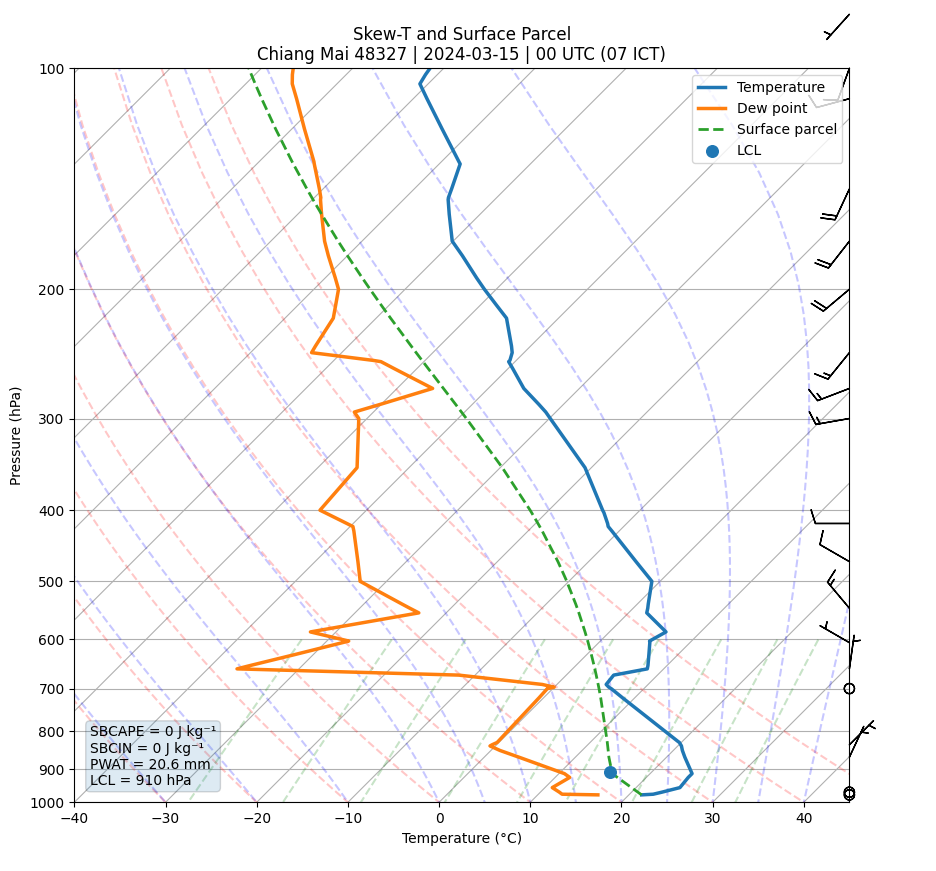

Saved: /content/drive/MyDrive/Teaching_Sounding_AirQuality/04_figures/03_complete_SkewT_2024-03-15.png


In [11]:
def quantity_is_finite(q):
    try:
        return np.isfinite(np.asarray(q.magnitude, dtype=float)).all()
    except Exception:
        return False

fig = plt.figure(figsize=(10, 10))
skew = SkewT(fig, rotation=45)

skew.plot(pressure, temperature, linewidth=2.5, label="Temperature")
skew.plot(pressure, dewpoint, linewidth=2.5, label="Dew point")
skew.plot(pressure, parcel, linewidth=2.0, linestyle="--", label="Surface parcel")

skew.plot_dry_adiabats(alpha=0.22)
skew.plot_moist_adiabats(alpha=0.22)
skew.plot_mixing_lines(alpha=0.22)

skew.ax.scatter(
    lcl_t.to("degC").magnitude,
    lcl_p.to("hPa").magnitude,
    s=70, zorder=5, label="LCL"
)

if quantity_is_finite(lfc_p) and quantity_is_finite(lfc_t):
    skew.ax.scatter(
        lfc_t.to("degC").magnitude,
        lfc_p.to("hPa").magnitude,
        marker="^", s=70, zorder=5, label="LFC"
    )

if quantity_is_finite(el_p) and quantity_is_finite(el_t):
    skew.ax.scatter(
        el_t.to("degC").magnitude,
        el_p.to("hPa").magnitude,
        marker="s", s=65, zorder=5, label="EL"
    )

wind = thermo.dropna(
    subset=["pressure_hPa", "wind_speed_ms", "wind_direction_deg"]
).copy()

if not wind.empty:
    speed = wind["wind_speed_ms"].to_numpy() * units("m/s")
    direction = wind["wind_direction_deg"].to_numpy() * units.degree
    u, v = mpcalc.wind_components(speed, direction)

    idx = np.linspace(
        0, len(wind) - 1,
        min(25, len(wind)),
        dtype=int
    )

    skew.plot_barbs(
        wind["pressure_hPa"].to_numpy()[idx] * units.hPa,
        u[idx], v[idx]
    )

skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 45)
skew.ax.set_xlabel("Temperature (°C)")
skew.ax.set_ylabel("Pressure (hPa)")
skew.ax.set_title(
    f"Skew-T and Surface Parcel\nChiang Mai 48327 | {SELECTED_DATE} | 00 UTC (07 ICT)"
)

text = (
    f"SBCAPE = {sbcape.to('J/kg').magnitude:.0f} J kg⁻¹\n"
    f"SBCIN = {sbcin.to('J/kg').magnitude:.0f} J kg⁻¹\n"
    f"PWAT = {pwat.to('mm').magnitude:.1f} mm\n"
    f"LCL = {lcl_p.to('hPa').magnitude:.0f} hPa"
)

skew.ax.text(
    0.02, 0.02, text,
    transform=skew.ax.transAxes,
    fontsize=10,
    verticalalignment="bottom",
    bbox={"boxstyle":"round", "alpha":0.15}
)

skew.ax.legend(loc="best")

full_fig = FIG_DIR / f"03_complete_SkewT_{SELECTED_DATE}.png"
fig.savefig(full_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", full_fig)

## 3.10 แปลง pressure level เป็นความสูงโดยประมาณ

LCL/LFC/EL มักรายงานเป็น pressure เราสามารถ interpolate กับ observed pressure–height profile เพื่อประมาณความสูง MSL ได้

ค่าที่ได้เป็นการประมาณจาก sounding profile ไม่ใช่การวัดฐานเมฆโดยตรง

In [12]:
def pressure_to_height(target_hpa, profile_df):
    x = (
        profile_df[["pressure_hPa", "height_m"]]
        .dropna()
        .drop_duplicates("pressure_hPa")
        .sort_values("pressure_hPa")
    )

    pvals = x["pressure_hPa"].to_numpy()
    zvals = x["height_m"].to_numpy()

    if target_hpa < pvals.min() or target_hpa > pvals.max():
        return np.nan

    return float(np.interp(target_hpa, pvals, zvals))

def qfloat(q, unit_name):
    try:
        val = np.asarray(q.to(unit_name).magnitude).item()
        return float(val) if np.isfinite(val) else np.nan
    except Exception:
        return np.nan

lcl_h = pressure_to_height(qfloat(lcl_p, "hPa"), profile)
lfc_h = pressure_to_height(qfloat(lfc_p, "hPa"), profile) if np.isfinite(qfloat(lfc_p, "hPa")) else np.nan
el_h = pressure_to_height(qfloat(el_p, "hPa"), profile) if np.isfinite(qfloat(el_p, "hPa")) else np.nan

level_table = pd.DataFrame({
    "level":["LCL","LFC","EL"],
    "pressure_hPa":[qfloat(lcl_p,"hPa"), qfloat(lfc_p,"hPa"), qfloat(el_p,"hPa")],
    "approx_height_m_MSL":[lcl_h, lfc_h, el_h]
})

display(level_table)

,level,pressure_hPa,approx_height_m_MSL
0,LCL,909.836447,941.639902
1,LFC,NaN,NaN
2,EL,NaN,NaN


## 3.11 สรุปค่าของ Sounding ที่เลือก

In [13]:
single_diag = pd.DataFrame([{
    "date": SELECTED_DATE,
    "LCL_pressure_hPa": qfloat(lcl_p, "hPa"),
    "LCL_height_m_MSL": lcl_h,
    "LFC_pressure_hPa": qfloat(lfc_p, "hPa"),
    "LFC_height_m_MSL": lfc_h,
    "EL_pressure_hPa": qfloat(el_p, "hPa"),
    "EL_height_m_MSL": el_h,
    "SBCAPE_Jkg": qfloat(sbcape, "J/kg"),
    "SBCIN_Jkg": qfloat(sbcin, "J/kg"),
    "MLCAPE_Jkg": qfloat(mlcape, "J/kg"),
    "MLCIN_Jkg": qfloat(mlcin, "J/kg"),
    "MUCAPE_Jkg": qfloat(mucape, "J/kg"),
    "MUCIN_Jkg": qfloat(mucin, "J/kg"),
    "PWAT_mm": qfloat(pwat, "mm"),
}])

display(single_diag.T)

,0
date,2024-03-15
LCL_pressure_hPa,909.836447
LCL_height_m_MSL,941.639902
LFC_pressure_hPa,NaN
LFC_height_m_MSL,NaN
EL_pressure_hPa,NaN
EL_height_m_MSL,NaN
SBCAPE_Jkg,0.0
SBCIN_Jkg,0.0
MLCAPE_Jkg,0.0


## 3.12 Temporal representativeness

00 UTC ที่เชียงใหม่คือประมาณ **07:00 ICT**

ดังนั้น surface heating ยังไม่พัฒนาเต็มที่ และ morning inversion อาจยังคงอยู่

จึงควรเรียกค่าที่ได้ว่า

> **morning thermodynamic environment**

ไม่ใช่ “daily maximum CAPE” หรือ “สภาวะสูงสุดของวัน”

นี่เป็นหลักสำคัญของการใช้ observation ในงานวิจัย

# 3.13 Batch diagnostics สำหรับ 61 Soundings

หลังจากเข้าใจ sounding หนึ่งวันแล้ว จะใช้ pipeline เดียวกันคำนวณทุกวัน เพื่อสร้างหนึ่งแถวต่อ sounding

ผลลัพธ์นี้จะใช้ใน Notebook 05 สำหรับการวิเคราะห์เชิงเวลาและสถิติ

In [14]:
def calculate_thermo(profile_df):
    x = (
        profile_df[["pressure_hPa","temperature_C","dewpoint_C"]]
        .dropna()
        .sort_values("pressure_hPa", ascending=False)
        .drop_duplicates("pressure_hPa")
        .reset_index(drop=True)
    )

    result = {"n_thermo_levels":len(x), "status":"ok"}

    if len(x) < 10:
        result["status"] = "insufficient_levels"
        return result

    p = x["pressure_hPa"].to_numpy() * units.hPa
    t = x["temperature_C"].to_numpy() * units.degC
    td = x["dewpoint_C"].to_numpy() * units.degC

    try:
        parcel_x = mpcalc.parcel_profile(p, t[0], td[0]).to("degC")
        lclp, _ = mpcalc.lcl(p[0], t[0], td[0])
        lfcp, _ = safe_lfc(p, t, td, parcel_x)
        elp, _ = safe_el(p, t, td, parcel_x)
        sbcape_x, sbcin_x = mpcalc.cape_cin(p, t, td, parcel_x)
        pw_x = mpcalc.precipitable_water(p, td)

        try:
            mlcape_x, mlcin_x = mpcalc.mixed_layer_cape_cin(
                p, t, td, depth=100*units.hPa
            )
        except Exception:
            mlcape_x = np.nan*units("J/kg")
            mlcin_x = np.nan*units("J/kg")

        try:
            mucape_x, mucin_x = mpcalc.most_unstable_cape_cin(
                p, t, td, depth=300*units.hPa
            )
        except Exception:
            mucape_x = np.nan*units("J/kg")
            mucin_x = np.nan*units("J/kg")

        result.update({
            "LCL_pressure_hPa":qfloat(lclp,"hPa"),
            "LFC_pressure_hPa":qfloat(lfcp,"hPa"),
            "EL_pressure_hPa":qfloat(elp,"hPa"),
            "SBCAPE_Jkg":qfloat(sbcape_x,"J/kg"),
            "SBCIN_Jkg":qfloat(sbcin_x,"J/kg"),
            "MLCAPE_Jkg":qfloat(mlcape_x,"J/kg"),
            "MLCIN_Jkg":qfloat(mlcin_x,"J/kg"),
            "MUCAPE_Jkg":qfloat(mucape_x,"J/kg"),
            "MUCIN_Jkg":qfloat(mucin_x,"J/kg"),
            "PWAT_mm":qfloat(pw_x,"mm"),
        })

    except Exception as exc:
        result["status"] = "calculation_error"
        result["error_message"] = str(exc)

    return result

In [15]:
rows = []

for launch, profile_day in df.groupby("launch_datetime_utc"):
    r = calculate_thermo(profile_day)
    r["launch_datetime_utc"] = launch
    r["date"] = launch.date()
    rows.append(r)

thermo_daily = (
    pd.DataFrame(rows)
    .sort_values("launch_datetime_utc")
    .reset_index(drop=True)
)

print("Diagnostics:", len(thermo_daily))
print("\nStatus:")
display(
    thermo_daily["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)

display(thermo_daily.head(10))

Diagnostics: 61

Status:


,status,count
0,ok,61


,n_thermo_levels,status,LCL_pressure_hPa,LFC_pressure_hPa,EL_pressure_hPa,SBCAPE_Jkg,SBCIN_Jkg,MLCAPE_Jkg,MLCIN_Jkg,MUCAPE_Jkg,MUCIN_Jkg,PWAT_mm,launch_datetime_utc,date
0,46,ok,985.271139,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,24.580944,2024-03-01,2024-03-01
1,53,ok,950.746277,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,24.944463,2024-03-02,2024-03-02
2,61,ok,928.615661,NaN,NaN,0.0,0.0,0.0,0.0,64.182534,0.0,29.905389,2024-03-03,2024-03-03
3,56,ok,932.701852,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,26.460255,2024-03-04,2024-03-04
4,54,ok,942.442941,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,26.023941,2024-03-05,2024-03-05
5,99,ok,905.278377,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,19.850210,2024-03-06,2024-03-06
6,87,ok,910.622395,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,22.922286,2024-03-07,2024-03-07
7,69,ok,913.044357,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,27.539278,2024-03-08,2024-03-08
8,81,ok,906.148725,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,18.541811,2024-03-09,2024-03-09
9,74,ok,881.764393,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,23.218061,2024-03-10,2024-03-10


## 3.14 ตรวจ Distribution ก่อนทำสถิติ

CAPE มักมี distribution แบบ skewed และอาจมีค่า 0 จำนวนมาก ดังนั้นภายหลังควรพิจารณา median, IQR และ non-parametric statistics ไม่ใช่ mean ± SD เพียงอย่างเดียว

In [16]:
diag_vars = [
    "SBCAPE_Jkg","SBCIN_Jkg",
    "MLCAPE_Jkg","MLCIN_Jkg",
    "MUCAPE_Jkg","MUCIN_Jkg",
    "PWAT_mm"
]

diag_vars = [c for c in diag_vars if c in thermo_daily.columns]

missing_diag = pd.DataFrame({
    "variable":diag_vars,
    "missing_n":[thermo_daily[c].isna().sum() for c in diag_vars]
})

print("Missing diagnostics:")
display(missing_diag)

print("\nDescriptive statistics:")
display(
    thermo_daily[diag_vars]
    .describe(percentiles=[0.10,0.25,0.50,0.75,0.90])
    .T
)

Missing diagnostics:


,variable,missing_n
0,SBCAPE_Jkg,0
1,SBCIN_Jkg,0
2,MLCAPE_Jkg,0
3,MLCIN_Jkg,0
4,MUCAPE_Jkg,0
5,MUCIN_Jkg,0
6,PWAT_mm,0



Descriptive statistics:


,count,mean,std,min,10%,25%,50%,75%,90%,max
SBCAPE_Jkg,61.0,693.546391,912.293770,-139.808446,0.000000,0.000000,214.069572,1179.034470,1760.357998,4007.453847
SBCIN_Jkg,61.0,-184.942535,175.310223,-578.257897,-434.554203,-308.166083,-169.113610,0.000000,0.000000,0.000000
MLCAPE_Jkg,61.0,107.276333,257.077947,-165.114837,0.000000,0.000000,0.000000,86.475118,401.687106,1312.984944
MLCIN_Jkg,61.0,-118.006563,147.878808,-609.193167,-315.358010,-227.025828,0.000000,0.000000,0.000000,0.000000
MUCAPE_Jkg,61.0,730.230294,918.115155,-139.808446,0.000000,0.000000,244.480778,1189.307102,1760.357998,4007.453847
MUCIN_Jkg,61.0,-167.937654,169.653309,-579.267820,-434.230621,-286.756125,-163.328870,0.000000,0.000000,0.000000
PWAT_mm,61.0,29.525822,6.801859,17.298896,19.850210,24.115000,30.958441,35.391091,37.118062,42.480807


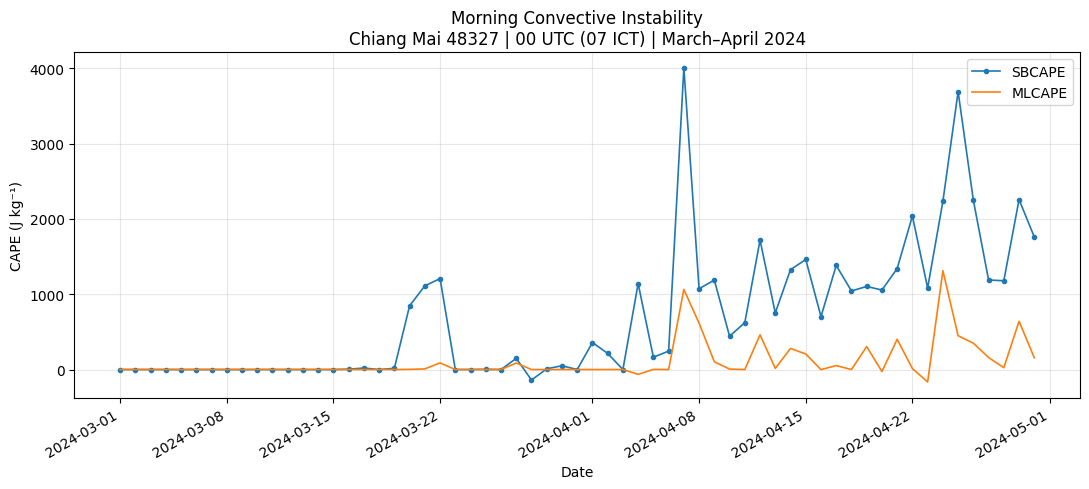

In [17]:
fig, ax = plt.subplots(figsize=(11,5))

ax.plot(
    pd.to_datetime(thermo_daily["date"]),
    thermo_daily["SBCAPE_Jkg"],
    marker="o", markersize=3, linewidth=1.2,
    label="SBCAPE"
)

if "MLCAPE_Jkg" in thermo_daily.columns:
    ax.plot(
        pd.to_datetime(thermo_daily["date"]),
        thermo_daily["MLCAPE_Jkg"],
        linewidth=1.2,
        label="MLCAPE"
    )

ax.set_xlabel("Date")
ax.set_ylabel("CAPE (J kg⁻¹)")
ax.set_title(
    "Morning Convective Instability\n"
    "Chiang Mai 48327 | 00 UTC (07 ICT) | March–April 2024"
)
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

ts_fig = FIG_DIR / "03_CAPE_timeseries_MarApr2024.png"
fig.savefig(ts_fig, dpi=300, bbox_inches="tight")
plt.show()

In [18]:
DAILY_FILE = OUTPUT_DIR / "03_daily_thermodynamic_diagnostics_48327_00UTC_MarApr2024.csv"
SINGLE_FILE = OUTPUT_DIR / f"03_thermodynamic_diagnostics_{SELECTED_DATE}.csv"

thermo_daily.to_csv(DAILY_FILE, index=False)
single_diag.to_csv(SINGLE_FILE, index=False)

print("Saved:")
print(" -", DAILY_FILE)
print(" -", SINGLE_FILE)
print("\nRows:", len(thermo_daily))

Saved:
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/03_daily_thermodynamic_diagnostics_48327_00UTC_MarApr2024.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/03_thermodynamic_diagnostics_2024-03-15.csv

Rows: 61


# 3.15 แบบฝึกหัด

### Exercise 1 — เปลี่ยนวัน
เปลี่ยน `SELECTED_DATE` อย่างน้อย 3 วัน แล้วเปรียบเทียบ Skew‑T, CAPE, CIN, LCL และ PWAT

### Exercise 2 — Parcel definition
หาวันที่ `MUCAPE > SBCAPE` ชัดเจน แล้วอภิปรายว่าทำไม most-unstable parcel อาจไม่ได้อยู่ที่ surface

### Exercise 3 — CAPE กับ CIN
หาวันที่ CAPE ค่อนข้างสูงแต่ CIN มีขนาดมาก แล้วตอบว่า “มี instability” เท่ากับ “เกิด convection แน่นอน” หรือไม่

### Exercise 4 — Morning sounding
อธิบายว่าทำไม CAPE เวลา 07:00 ICT อาจแตกต่างจากช่วงบ่าย โดยพิจารณา solar heating, boundary-layer mixing และ moisture redistribution

### Exercise 5 — PWAT
เลือกวัน PWAT ต่ำและสูง แล้วเปรียบเทียบความแตกต่างระหว่าง \(T\) และ \(T_d\) บน Skew‑T

---

# สรุป

1. Skew‑T ใช้อธิบาย thermodynamic structure
2. Parcel profile เป็นแบบจำลอง parcel ที่ถูกยกตัว
3. LCL, LFC และ EL มีความหมายต่างกัน
4. CAPE คือ potential buoyant energy ส่วน CIN คือ inhibition
5. SBCAPE, MLCAPE และ MUCAPE ใช้ parcel definition ต่างกัน
6. PWAT แทน column moisture
7. ดัชนีต้องตีความร่วมกับ profile จริง
8. 00 UTC = 07:00 ICT จึงเป็น morning environment
9. Notebook นี้สร้าง thermodynamic diagnostics สำหรับ 61 วันไว้แล้ว

## Notebook ต่อไป

`04_stability_inversion_and_air_pollution.ipynb`

จะเน้น:

- potential-temperature gradient
- lapse rate
- temperature inversion
- inversion base/top/depth/strength
- Brunt–Väisälä frequency
- lower-level wind
- Bulk Richardson Number
- morning boundary-layer diagnostic
- ventilation coefficient
- ความเชื่อมโยงกับการสะสมและการระบายมลพิษ